**LIBRERÍAS**

In [68]:
import pandas as pd
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown
import zipfile
import os
import torch.optim as optim
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, ADASYN
from imblearn.combine import SMOTEENN
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
)

**DESCARGA DEL DATASET**

In [69]:
url = "https://drive.google.com/file/d/1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ/view?usp=drive_link"
zip_filename = "dataset.zip"
extract_dir = "./dataset_extraido"

gdown.download(url, zip_filename, quiet=False)

if os.path.exists(zip_filename):
    with zipfile.ZipFile(zip_filename, "r") as zip_ref:
        zip_ref.extractall(extract_dir)
    print(f"Archivo descomprimido con éxito en: {extract_dir}")

ruta_csv = os.path.join("./dataset_extraido/healthcare-dataset-stroke-data.csv")
df = pd.read_csv(ruta_csv)
df_copia = df.copy()  # copia de resguardo del df original

Downloading...
From: https://drive.google.com/uc?id=1CZOPvXzpA48GC2WVsmA5hZvyQugDQ6sQ
To: c:\Users\Gabi\Proyectos\AA2_TP1\dataset.zip
100%|██████████| 69.0k/69.0k [00:00<00:00, 1.36MB/s]

Archivo descomprimido con éxito en: ./dataset_extraido


**EDA**

| Columna | Tipo de dato | Descripción | Valores / Rango |
| :--- | :--- | :--- | :--- |
| **id** | Entero (ID) | Identificador único del paciente | Número entero de identificación |
| **gender** | Categórico | Género del paciente | `"Male"`, `"Female"`, `"Other"` |
| **age** | Numérico (Continuo) | Edad del paciente en años | Número flotante o entero |
| **hypertension** | Binario (Nominal) | Presencia de hipertensión arterial previa | `0` = No, `1` = Sí |
| **heart_disease** | Binario (Nominal) | Presencia de enfermedad cardíaca previa | `0` = No, `1` = Sí |
| **ever_married** | Categórico | Indica si el paciente ha estado casado alguna vez | `"Yes"`, `"No"` |
| **work_type** | Categórico | Tipo de ocupación o relación laboral | `"Private"`, `"Self-employed"`, `"Govt_job"`, `"children"`, `"Never_worked"` |
| **Residence_type** | Categórico | Tipo de zona de residencia | `"Urban"`, `"Rural"` |
| **avg_glucose_level** | Numérico (Continuo) | Nivel promedio de glucosa en sangre (mg/dL) | Número flotante |
| **bmi** | Numérico (Continuo) | Índice de masa corporal ($\text{kg/m}^2$) | Número flotante (contiene valores nulos / `"N/A"`) |
| **smoking_status** | Categórico | Estado actual o histórico de consumo de tabaco | `"formerly smoked"`, `"never smoked"`, `"smokes"`, `"Unknown"` |
| **stroke** | Binario (Target) | Indica si el paciente sufrió un accidente cerebrovascular | `0` = No, `1` = Sí |

In [70]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   str    
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   str    
 6   work_type          5110 non-null   str    
 7   Residence_type     5110 non-null   str    
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   str    
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), str(5)
memory usage: 479.2 KB


In [72]:
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [73]:
total_duplicados = df.duplicated().sum()
print(f"Total de filas completas duplicadas: {total_duplicados}")

ids_duplicados = df.duplicated(subset=["id"]).sum()
print(f"Total de IDs duplicados: {ids_duplicados}")

Total de filas completas duplicadas: 0
Total de IDs duplicados: 0


In [74]:
print(
    pd.DataFrame(
        {
            "Total_Nulos": df.isnull().sum(),
            "Porcentaje_%": (df.isnull().sum() / len(df)) * 100,
        }
    )
)

                   Total_Nulos  Porcentaje_%
id                           0      0.000000
gender                       0      0.000000
age                          0      0.000000
hypertension                 0      0.000000
heart_disease                0      0.000000
ever_married                 0      0.000000
work_type                    0      0.000000
Residence_type               0      0.000000
avg_glucose_level            0      0.000000
bmi                        201      3.933464
smoking_status               0      0.000000
stroke                       0      0.000000


**DESBALANCEO DE LA VARIABLE OBJETIVO**

In [75]:
df.value_counts("stroke")

stroke
0    4861
1     249
Name: count, dtype: int64

**SPLIT**

In [76]:
X = df.drop(columns=["stroke", "id"])
y = df["stroke"]

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)

print(f"Dimensiones de X_train: {X_train.shape} ({len(X_train) / len(df):.0%})")
print(f"Dimensiones de X_val:   {X_val.shape} ({len(X_val) / len(df):.0%})")
print(f"Dimensiones de X_test:  {X_test.shape} ({len(X_test) / len(df):.0%})")

print("\n--- Distribución de 'stroke' (Proporción %) ---")
print(f"Original: \n{y.value_counts(normalize=True).round(4)}")
print(f"Train:    \n{y_train.value_counts(normalize=True).round(4)}")
print(f"Val:      \n{y_val.value_counts(normalize=True).round(4)}")
print(f"Test:     \n{y_test.value_counts(normalize=True).round(4)}")

Dimensiones de X_train: (3066, 10) (60%)
Dimensiones de X_val:   (1022, 10) (20%)
Dimensiones de X_test:  (1022, 10) (20%)

--- Distribución de 'stroke' (Proporción %) ---
Original: 
stroke
0    0.9513
1    0.0487
Name: proportion, dtype: float64
Train:    
stroke
0    0.9514
1    0.0486
Name: proportion, dtype: float64
Val:      
stroke
0    0.9511
1    0.0489
Name: proportion, dtype: float64
Test:     
stroke
0    0.9511
1    0.0489
Name: proportion, dtype: float64


## Imputación de BMI

In [77]:
bins = [0, 20, 40, 60, 80, 100]
labels = ["0-20", "20-40", "40-60", "60-80", "80-100"]

# Se preserva train antes de completar los faltantes.
X_train_antes = X_train.copy()
mask_imputados = X_train_antes["bmi"].isna()

# Se obtienen las medianas a partir del BMI observado en train.
X_train_grupos = X_train_antes.copy()
X_train_grupos["age_group"] = pd.cut(
    X_train_grupos["age"], bins=bins, labels=labels, right=False, include_lowest=True
)

bmi_medians = X_train_grupos.groupby(["age_group", "gender"], observed=True)[
    "bmi"
].median()
bmi_global = X_train_antes["bmi"].median()


### Verificación de las medianas por grupo

Se calcula la cantidad de BMI observados y faltantes, la mediana y el rango intercuartílico por edad y género. Se señalan los grupos con menos de 10 observaciones como advertencia exploratoria; ese valor no constituye un criterio estadístico de suficiencia. Se verifica la disponibilidad de medianas para los faltantes de train y validación, sin aprender parámetros de validación.


In [78]:
# BMI original por rango de edad y género
resumen_bmi = X_train_grupos.groupby(
    ["age_group", "gender"], observed=True, dropna=False
)["bmi"].agg(
    pacientes="size",
    observados="count",
    mediana="median",
    q1=lambda x: x.quantile(0.25),
    q3=lambda x: x.quantile(0.75),
)
resumen_bmi["faltantes"] = resumen_bmi["pacientes"] - resumen_bmi["observados"]
resumen_bmi["faltantes_pct"] = 100 * resumen_bmi["faltantes"] / resumen_bmi["pacientes"]
resumen_bmi["iqr"] = resumen_bmi["q3"] - resumen_bmi["q1"]
resumen_bmi["diferencia_mediana_global"] = resumen_bmi["mediana"] - bmi_global
resumen_bmi["pocas_observaciones"] = resumen_bmi["observados"] < 10
resumen_bmi = resumen_bmi[
    [
        "pacientes",
        "observados",
        "faltantes",
        "faltantes_pct",
        "mediana",
        "iqr",
        "diferencia_mediana_global",
        "pocas_observaciones",
    ]
]
display(resumen_bmi.round(2))

print(f"Mediana global observada de train: {bmi_global:.2f}")
print(
    f"Grupos con menos de 10 BMI observados: {int(resumen_bmi['pocas_observaciones'].sum())}"
)
print(f"Grupos sin BMI observado: {int(resumen_bmi['observados'].eq(0).sum())}")

# Se comprueba si los faltantes tienen una mediana de grupo disponible.
for nombre, datos in [("Train", X_train_antes), ("Validación", X_val)]:
    grupos = pd.cut(
        datos["age"], bins=bins, labels=labels, right=False, include_lowest=True
    )
    claves = pd.MultiIndex.from_arrays(
        [grupos, datos["gender"]], names=["age_group", "gender"]
    )
    medianas_disponibles = pd.Series(
        claves.map(bmi_medians).to_numpy(), index=datos.index
    )
    faltantes = datos["bmi"].isna()
    usa_respaldo = faltantes & medianas_disponibles.isna()
    print(
        f"{nombre}: {int(faltantes.sum())} BMI faltantes; "
        f"{int(usa_respaldo.sum())} requieren mediana global."
    )


pacientes  observados  faltantes  faltantes_pct  mediana  \
age_group gender                                                             
0-20      Female        285         278          7           2.46    20.60   
          Male          279         270          9           3.23    20.00   
20-40     Female        492         481         11           2.24    27.60   
          Male          238         225         13           5.46    28.80   
          Other           1           1          0           0.00    22.40   
40-60     Female        555         542         13           2.34    30.10   
          Male          384         364         20           5.21    31.05   
60-80     Female        422         395         27           6.40    29.70   
          Male          304         268         36          11.84    29.50   
80-100    Female         69          66          3           4.35    27.10   
          Male           37          37          0           0.00    28.70   

                    iqr  diferencia_mediana_global  pocas_observaciones  
age_group gender                                                         
0-20      Female   6.35                      -7.50                False  
          Male     5.77                      -8.10                False  
20-40     Female  10.40                      -0.50                False  
          Male     7.80                       0.70                False  
          Other    0.00                      -5.70                 True  
40-60     Female  10.48                       2.00                False  
          Male     7.95                       2.95                False  
60-80     Female   8.50                       1.60                False  
          Male     6.50                       1.40                False  
80-100    Female   8.40                      -1.00                False  
          Male     4.10                       0.60                False

Mediana global observada de train: 28.10
Grupos con menos de 10 BMI observados: 1
Grupos sin BMI observado: 0
Train: 139 BMI faltantes; 0 requieren mediana global.
Validación: 31 BMI faltantes; 0 requieren mediana global.


### Interpretación del resumen

Se observa una mediana global de BMI de 28.10 y diferencias principalmente entre rangos etarios: las medianas se sitúan entre 20.00 y 20.60 en menores de 20 años y entre 30.10 y 31.05 en el grupo de 40–60 años. Las diferencias entre Female y Male dentro de cada rango son menores, lo que respalda descriptivamente la agrupación por edad más que la incorporación de género.

El único grupo con menos de 10 observaciones corresponde a Other (un paciente), sin BMI faltante. Todos los grupos cuentan con BMI observado, por lo que los 139 faltantes de train y los 31 de validación se pueden completar con sus medianas de grupo, sin recurrir al respaldo global. La mayor proporción de faltantes se registra en Male de 60–80 años (11.84 %).

### Distribución del BMI observado por grupo

Se visualizan las distribuciones de BMI observado por edad y género, junto con la mediana global de entrenamiento como referencia.


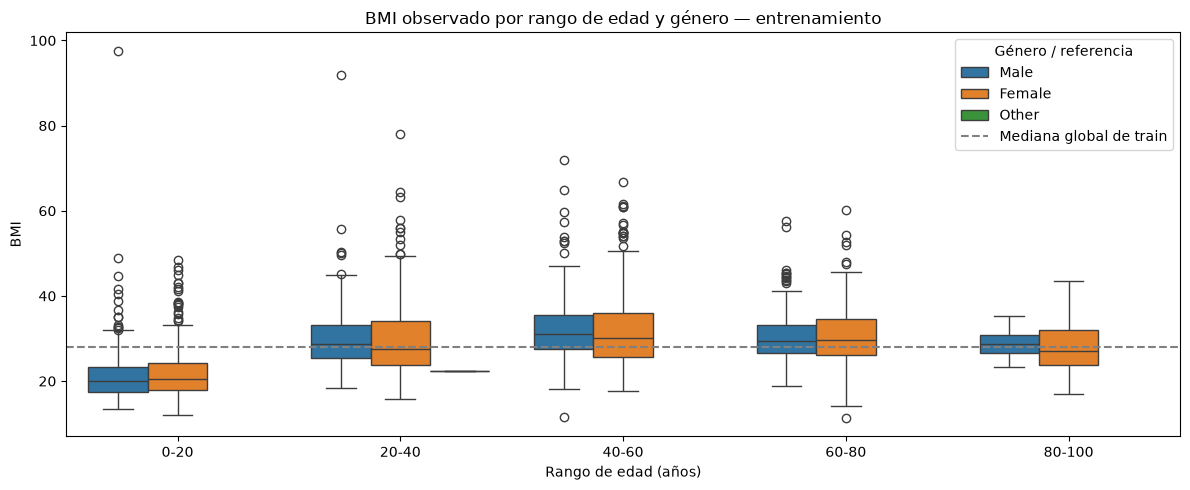

In [79]:
# Se visualizan únicamente los valores observados antes de imputar.
fig, ax = plt.subplots(figsize=(12, 5))
sns.boxplot(
    data=X_train_grupos.dropna(subset=["bmi"]),
    x="age_group",
    y="bmi",
    hue="gender",
    ax=ax,
)
ax.axhline(bmi_global, color="gray", linestyle="--", label="Mediana global de train")
ax.set_title("BMI observado por rango de edad y género — entrenamiento")
ax.set_xlabel("Rango de edad (años)")
ax.set_ylabel("BMI")
ax.legend(title="Género / referencia")
plt.tight_layout()
plt.show()


Se observan medianas inferiores a la referencia global (28.10) en menores de 20 años, superiores en el rango de 40–60 años y próximas a ella en los grupos de 20–40 y 80–100 años. En 60–80 años se mantienen ligeramente por encima de la referencia. Las distribuciones de Female y Male presentan un amplio solapamiento dentro de cada rango, con diferencias de mediana menores que las observadas entre edades.

Se registran valores atípicos superiores en varios grupos, lo que respalda el uso de una medida robusta como la mediana. La categoría Other se representa con una única observación y no permite caracterizar una distribución. El gráfico respalda descriptivamente la agrupación por edad, pero no demuestra una mejora predictiva de la imputación por grupos.

### Aplicación de la imputación a train, validación y test
Se completan los BMI faltantes con las medianas obtenidas de train, conservando los valores observados.

In [80]:
# Se aplican las mismas medianas de train a los tres conjuntos.
def imputar_bmi(df, bmi_medians, bmi_global, bins, labels):
    df = df.copy()
    df["age_group"] = pd.cut(
        df["age"], bins=bins, labels=labels, right=False, include_lowest=True
    )
    medianas = df.set_index(["age_group", "gender"]).index.map(bmi_medians)
    df["bmi"] = df["bmi"].fillna(pd.Series(medianas, index=df.index))
    df["bmi"] = df["bmi"].fillna(bmi_global)
    return df.drop(columns="age_group")


X_train = imputar_bmi(X_train_antes, bmi_medians, bmi_global, bins, labels)
X_val = imputar_bmi(X_val, bmi_medians, bmi_global, bins, labels)
X_test = imputar_bmi(X_test, bmi_medians, bmi_global, bins, labels)

print(
    f"BMI faltantes en train: {mask_imputados.sum()} antes -> {X_train['bmi'].isna().sum()} después"
)
print(
    f"BMI faltantes después: val={X_val['bmi'].isna().sum()}, test={X_test['bmi'].isna().sum()}"
)


BMI faltantes en train: 139 antes -> 0 después
BMI faltantes después: val=0, test=0


## Comparación antes y depsués de la imputación

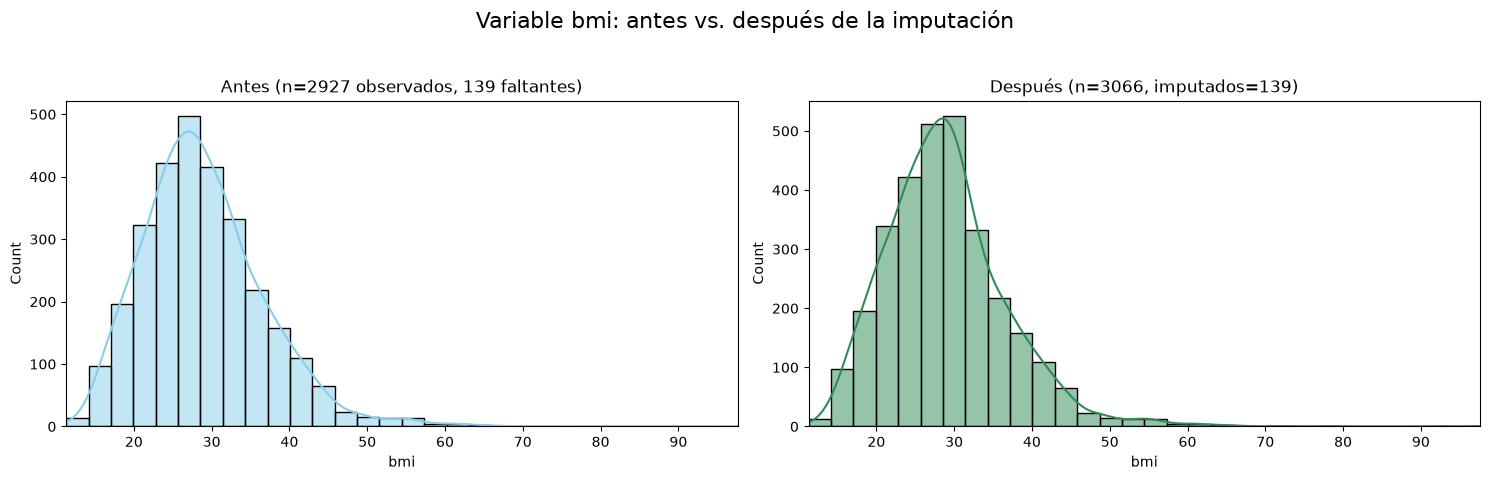

In [81]:
X_train_despues = X_train.copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Variable bmi: antes vs. después de la imputación", fontsize=16)

# mismos intervalos para comparar ambas distribuciones.
xmin, xmax = X_train_despues["bmi"].min(), X_train_despues["bmi"].max()
bins_hist = np.linspace(xmin, xmax, 31)

sns.histplot(
    data=X_train_antes, x="bmi", bins=bins_hist, kde=True, ax=axes[0], color="skyblue"
)
axes[0].set_title(
    f"Antes (n={X_train_antes['bmi'].notna().sum()} observados, {mask_imputados.sum()} faltantes)"
)

sns.histplot(
    data=X_train_despues,
    x="bmi",
    bins=bins_hist,
    kde=True,
    ax=axes[1],
    color="seagreen",
)
axes[1].set_title(
    f"Después (n={X_train_despues['bmi'].notna().sum()}, imputados={mask_imputados.sum()})"
)

for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


No se observan cambios mayores en la distribución. Se imputan 139 faltantes (4,53%)

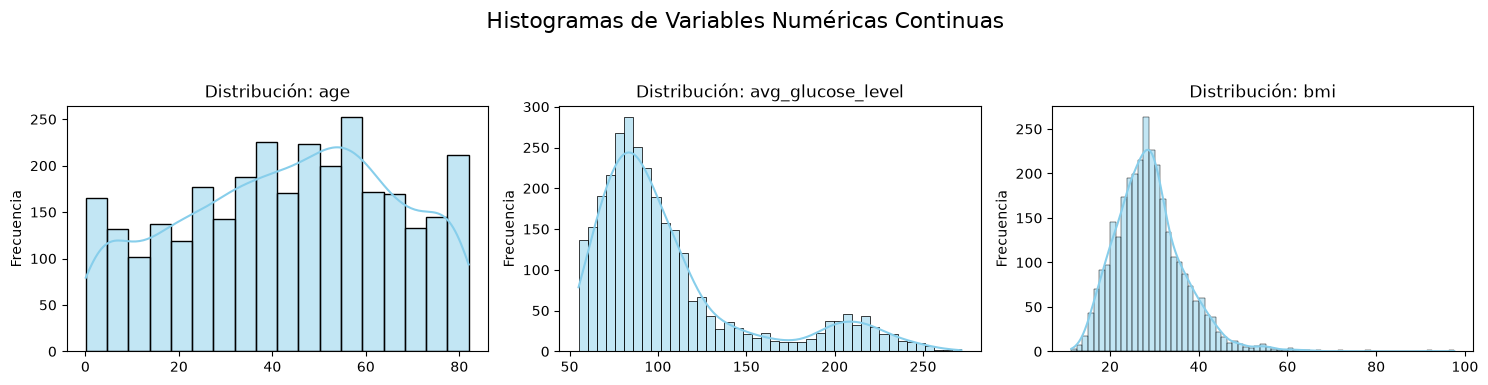

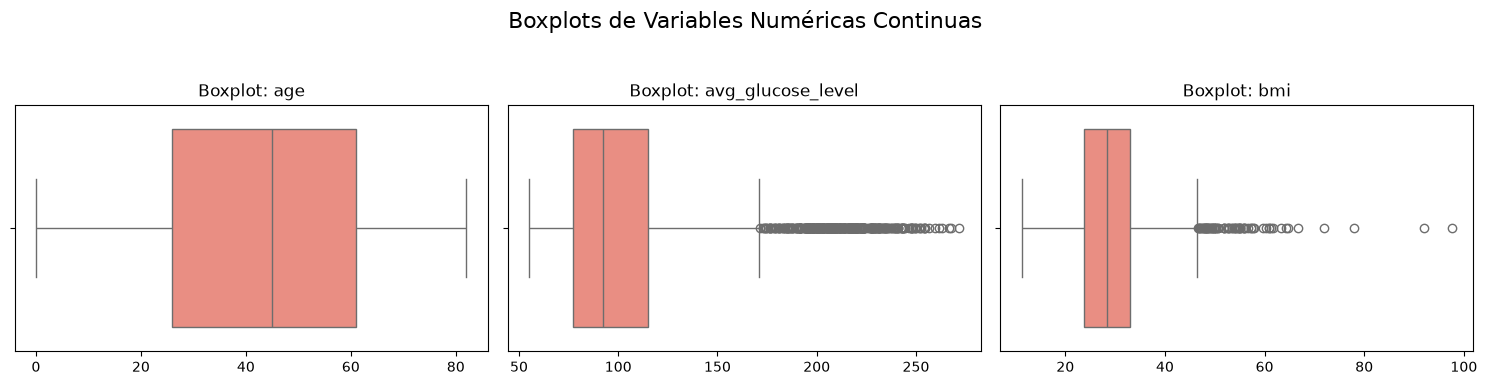

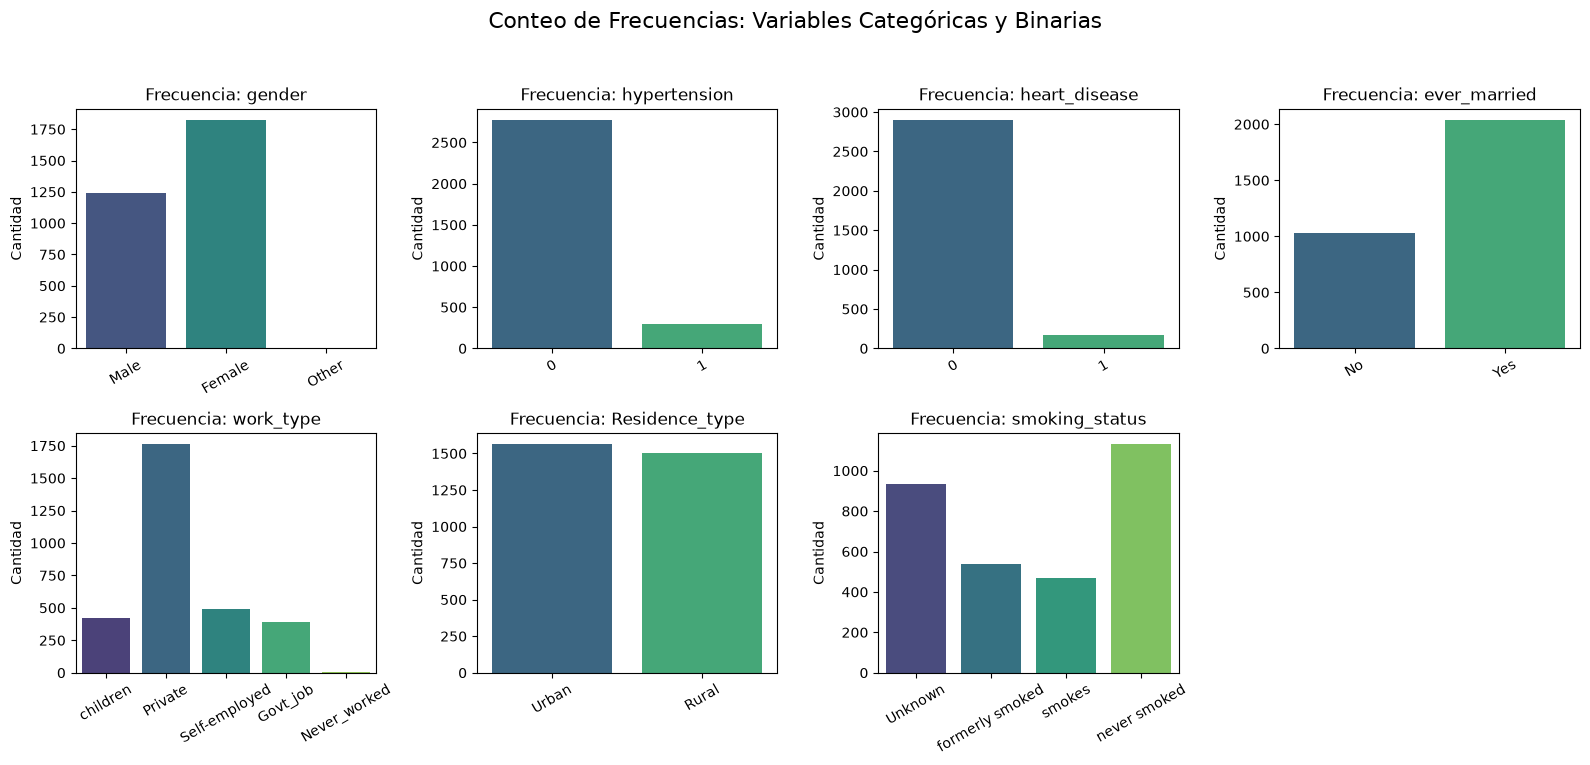

In [82]:
vars_numericas = ["age", "avg_glucose_level", "bmi"]
vars_categoricas = [
    "gender",
    "hypertension",
    "heart_disease",
    "ever_married",
    "work_type",
    "Residence_type",
    "smoking_status",
]

cols = 3
rows = int(np.ceil(len(vars_numericas) / cols))

fig, axes = plt.subplots(rows, cols, figsize=(15, 4))
fig.suptitle("Histogramas de Variables Numéricas Continuas", fontsize=16)

axes_flat = np.array(axes).flatten()

for i, col in enumerate(vars_numericas):
    sns.histplot(data=X_train, x=col, kde=True, ax=axes_flat[i], color="skyblue")
    axes_flat[i].set_title(f"Distribución: {col}")
    axes_flat[i].set_xlabel("")
    axes_flat[i].set_ylabel("Frecuencia")

for j in range(len(vars_numericas), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

fig, axes = plt.subplots(rows, cols, figsize=(15, 4))
fig.suptitle("Boxplots de Variables Numéricas Continuas", fontsize=16)

axes_flat = np.array(axes).flatten()

for i, col in enumerate(vars_numericas):
    sns.boxplot(data=X_train, x=col, ax=axes_flat[i], color="salmon")
    axes_flat[i].set_title(f"Boxplot: {col}")
    axes_flat[i].set_xlabel("")

for j in range(len(vars_numericas), len(axes_flat)):
    fig.delaxes(axes_flat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()

cols_cat = 4
rows_cat = int(np.ceil(len(vars_categoricas) / cols_cat))

fig, axes = plt.subplots(rows_cat, cols_cat, figsize=(16, 8))
fig.suptitle("Conteo de Frecuencias: Variables Categóricas y Binarias", fontsize=16)

axes_flat_cat = np.array(axes).flatten()

for i, col in enumerate(vars_categoricas):
    ax = axes_flat_cat[i]
    sns.countplot(data=X_train, x=col, ax=ax, palette="viridis", hue=col, legend=False)
    ax.set_title(f"Frecuencia: {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Cantidad")
    ax.tick_params(axis="x", rotation=30)

for j in range(len(vars_categoricas), len(axes_flat_cat)):
    fig.delaxes(axes_flat_cat[j])

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

C:\Users\Gabi\AppData\Local\Temp\ipykernel_34036\721246235.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Gabi\AppData\Local\Temp\ipykernel_34036\721246235.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


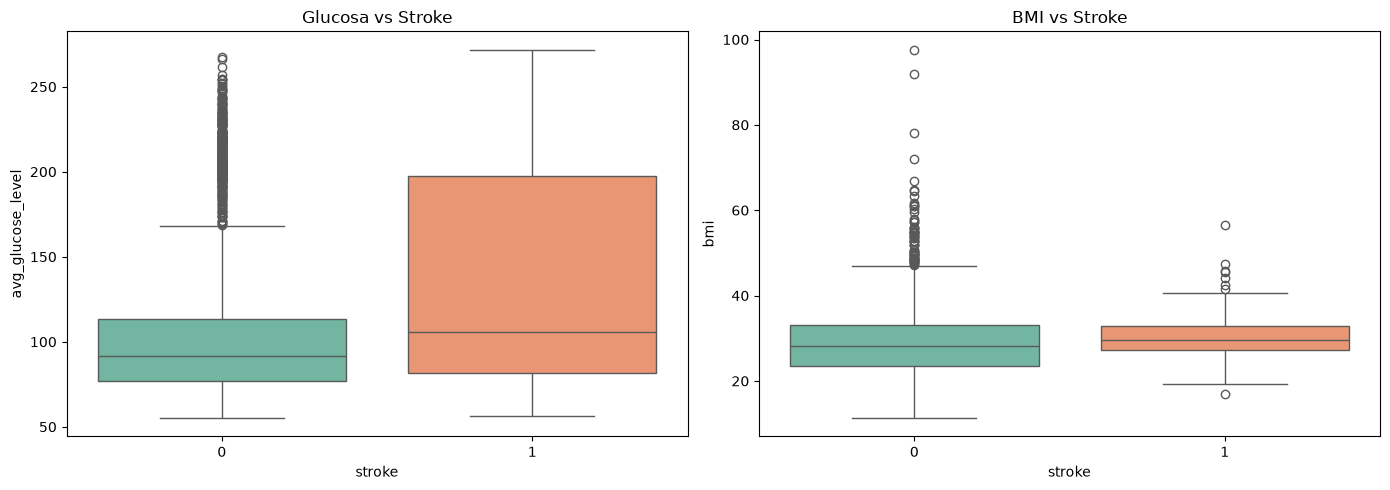

In [83]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=X_train.assign(stroke=y_train),
    x="stroke",
    y="avg_glucose_level",
    ax=axes[0],
    palette="Set2",
)
axes[0].set_title("Glucosa vs Stroke")

sns.boxplot(
    data=X_train.assign(stroke=y_train), x="stroke", y="bmi", ax=axes[1], palette="Set2"
)
axes[1].set_title("BMI vs Stroke")

plt.tight_layout()
plt.show()

C:\Users\Gabi\AppData\Local\Temp\ipykernel_34036\3161715585.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_corr.select_dtypes(include=["object", "category"]).columns:


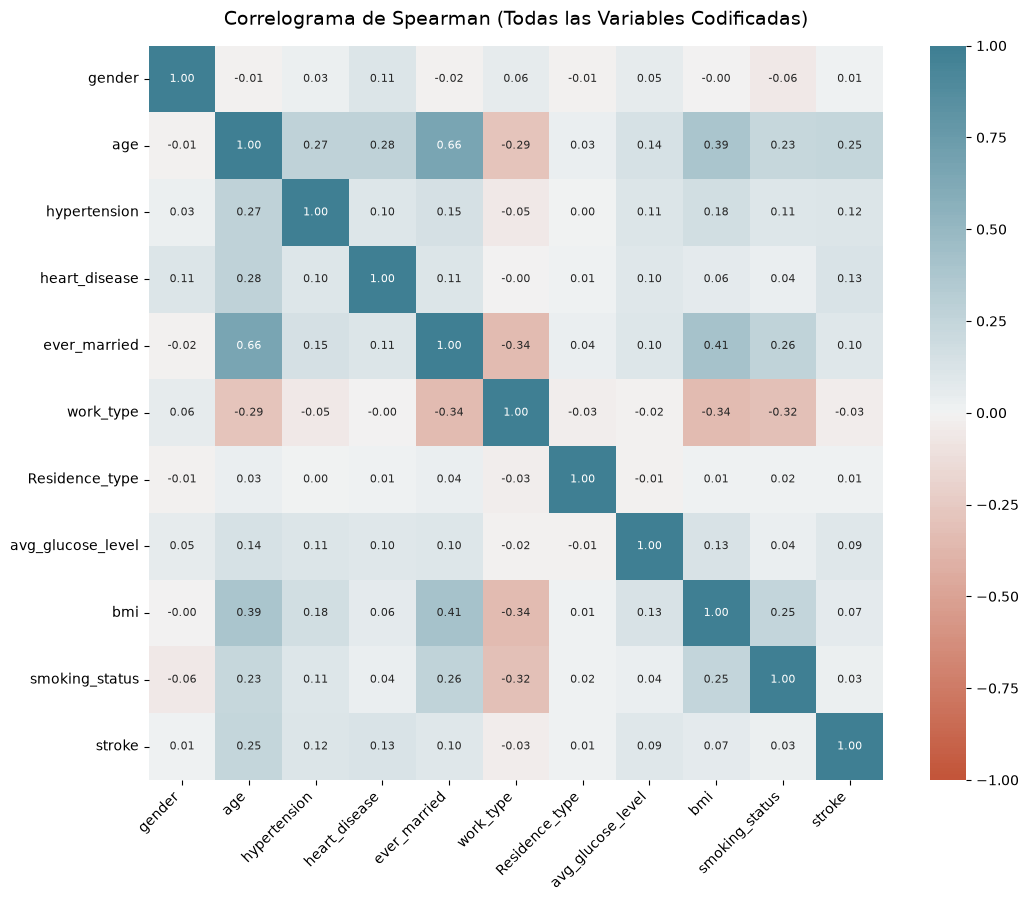

In [84]:
df_train = pd.concat([X_train, y_train], axis=1)
df_corr = df_train.copy()

for col in df_corr.select_dtypes(include=["object", "category"]).columns:
    df_corr[col] = df_corr[col].astype("category").cat.codes

if "id" in df_corr.columns:
    df_corr = df_corr.drop(columns=["id"])

corr = df_corr.corr(method="spearman")

plt.figure(figsize=(11, 9))
ax = sns.heatmap(
    corr,
    vmin=-1,
    vmax=1,
    center=0,
    cmap=sns.diverging_palette(20, 220, n=200),
    square=True,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8},
)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, horizontalalignment="right")
plt.title(
    "Correlograma de Spearman (Todas las Variables Codificadas)", fontsize=14, pad=15
)
plt.tight_layout()
plt.show()

## Codificación y escalado

In [85]:
preprocessor = ColumnTransformer(
    transformers=[
        ("numericas", StandardScaler(), vars_numericas),
        (
            "categoricas",
            OneHotEncoder(drop="first", sparse_output=False),
            vars_categoricas,
        ),
    ]
)


X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

print(f"Forma de X_train procesado: {X_train_prep.shape}")
print(f"Forma de X_val procesado:   {X_val_prep.shape}")
print(f"Forma de X_test procesado:  {X_test_prep.shape}")

Forma de X_train procesado: (3066, 16)
Forma de X_val procesado:   (1022, 16)
Forma de X_test procesado:  (1022, 16)


## Tratamiento del desbalance

Como primer aproximación se decidió resolver el desbalance mediante SMOTE, usando BorderlineSMOTE

In [86]:
# adasyn = ADASYN(random_state=42)

border_smote = BorderlineSMOTE(random_state=42)
X_train_smote, y_train_smote = border_smote.fit_resample(X_train_prep, y_train)

num_features = X_train_smote.shape[1]

print("--- Distribución de 'stroke' antes de ADASYN ---")
print(y_train.value_counts())

print("\n--- Distribución de 'stroke' después de ADASYN ---")
print(pd.Series(y_train_smote).value_counts())

--- Distribución de 'stroke' antes de ADASYN ---
stroke
0    2917
1     149
Name: count, dtype: int64

--- Distribución de 'stroke' después de ADASYN ---
stroke
0    2917
1    2917
Name: count, dtype: int64


## Entrenamiento

Se probará un MLP de 128 neuronas, ReLU, dropout 0.2, Adam y learning rate 0.0001. La pérdida que vaya teniendo train se evalua contra validación en cada época. Se seleccionan los pesos cuando mejora al menos min_delta. Se detiene el entrenamiento al alcanzar la paciencia establecida y se restauran los pesos seleccionados. Validación pasa por la red para medir, pero no por `backward()` ni `optimizer.step()`.

- **Train sobremuestreado:** ajusta los pesos en minibatches.
- **Train original:** se evalúa al terminar cada época para registrar curvas con el desbalance original.
- **Validación:** se evalúa al terminar cada época, sin sobremuestreo, y selecciona el checkpoint.
- **Test:** no interviene en este bloque.

El recall se registra con umbral fijo 0.5. `patience=10` y `min_delta=1e-4` son valores iniciales explícitos. Las semillas se fijan antes de inicializar el modelo; no garantizan identidad entre distintas plataformas.

Las salidas guardadas fueron regeneradas con el CSV local al verificar la comparación.


In [87]:
import copy
import random

# Semillas antes de inicializar pesos y barajar los minibatches.
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        out = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(out)


# Train sobremuestreado: es el único conjunto que actualiza pesos.
X_train_tensor = torch.tensor(np.asarray(X_train_smote), dtype=torch.float32)
y_train_tensor = torch.tensor(np.asarray(y_train_smote), dtype=torch.float32).view(
    -1, 1
)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Validación: mismos pasos de preprocesamiento, sin sobremuestreo.
X_val_tensor = torch.tensor(np.asarray(X_val_prep), dtype=torch.float32)
y_val_tensor = torch.tensor(np.asarray(y_val), dtype=torch.float32).view(-1, 1)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# Train original para diagnosticar curvas con el desbalance real.
X_train_original_tensor = torch.tensor(np.asarray(X_train_prep), dtype=torch.float32)
y_train_original_tensor = torch.tensor(np.asarray(y_train), dtype=torch.float32).view(
    -1, 1
)
train_original_dataset = TensorDataset(X_train_original_tensor, y_train_original_tensor)
train_eval_loader = DataLoader(train_original_dataset, batch_size=64, shuffle=False)

model = MLP(input_dim=num_features, hidden_dim=128, dropout_rate=0.2)
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-4)


def evaluar_modelo(loader):
    # eval() apaga dropout; no_grad() evita calcular gradientes.
    model.eval()
    loss_sum = 0.0
    total = 0
    true_positives = 0
    false_negatives = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            logits = model(batch_x)
            loss_sum += criterion(logits, batch_y).item() * batch_x.size(0)
            total += batch_x.size(0)
            # Umbral fijo 0.5: equivale a logits >= 0. No se busca un umbral aquí.
            predictions = logits >= 0
            positives = batch_y == 1
            true_positives += (predictions & positives).sum().item()
            false_negatives += ((~predictions) & positives).sum().item()
    if total == 0:
        raise ValueError("No se puede evaluar un conjunto vacío.")
    positive_count = true_positives + false_negatives
    recall = true_positives / positive_count if positive_count else float("nan")
    return loss_sum / total, recall


epochs = 200
patience = 10
min_delta = 1e-4
best_val_loss = float("inf")
best_model_weights = None
best_epoch = None
epochs_without_improvement = 0
history = []

print("Train actualiza pesos; validación selecciona la época; test no participa.")
for epoch in range(1, epochs + 1):
    model.train()  # Reactivar dropout tras las evaluaciones de la época anterior.
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * batch_x.size(0)

    # Evaluación de train original y val con los mismos pesos y dropout apagado.
    train_loss, train_recall = evaluar_modelo(train_eval_loader)
    val_loss, val_recall = evaluar_modelo(val_loader)
    history.append(
        {
            "epoch": epoch,
            "optimization_loss": running_loss / len(train_dataset),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_recall": train_recall,
            "val_recall": val_recall,
        }
    )
    improved = val_loss < best_val_loss - min_delta
    if improved:
        best_val_loss = val_loss
        best_epoch = epoch
        # Copia independiente en memoria: no sobrescribe archivos de checkpoints.
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    # Todas las métricas siguen en history; solo se reduce la salida de consola.
    if epoch % 10 == 0 or epochs_without_improvement == 1:
        status = (
            "Mejora de validación"
            if improved
            else f"Sin mejora suficiente | Paciencia: {epochs_without_improvement}/{patience}"
        )
        print(
            f"Época {epoch:02d}/{epochs} | Loss train: {train_loss:.4f} "
            f"| Loss val: {val_loss:.4f} | Recall train: {train_recall:.3f} "
            f"| Recall val: {val_recall:.3f} | {status}"
        )

    if epochs_without_improvement >= patience:
        print(f"Early stopping: {patience} épocas sin mejora suficiente.")
        break

if best_model_weights is None:
    raise RuntimeError("No se obtuvo un checkpoint válido; revisar datos y pérdidas.")
model.load_state_dict(best_model_weights)
model.eval()
print(f"Mejores pesos restaurados: época {best_epoch}, val loss = {best_val_loss:.4f}")

# Conservar este experimento separado de la alternativa con pos_weight.
model_smote = copy.deepcopy(model)


Train actualiza pesos; validación selecciona la época; test no participa.
Época 02/200 | Loss train: 0.6125 | Loss val: 0.6141 | Recall train: 0.785 | Recall val: 0.780 | Sin mejora suficiente | Paciencia: 1/10
Época 10/200 | Loss train: 0.4699 | Loss val: 0.4667 | Recall train: 0.799 | Recall val: 0.820 | Mejora de validación
Época 20/200 | Loss train: 0.4228 | Loss val: 0.4171 | Recall train: 0.779 | Recall val: 0.720 | Mejora de validación
Época 24/200 | Loss train: 0.4137 | Loss val: 0.4074 | Recall train: 0.765 | Recall val: 0.720 | Sin mejora suficiente | Paciencia: 1/10
Época 27/200 | Loss train: 0.4109 | Loss val: 0.4040 | Recall train: 0.765 | Recall val: 0.700 | Sin mejora suficiente | Paciencia: 1/10
Época 29/200 | Loss train: 0.4105 | Loss val: 0.4033 | Recall train: 0.772 | Recall val: 0.700 | Sin mejora suficiente | Paciencia: 1/10
Época 30/200 | Loss train: 0.4104 | Loss val: 0.4033 | Recall train: 0.779 | Recall val: 0.700 | Sin mejora suficiente | Paciencia: 2/10
Época

## Curvas de entrenamiento (train vs validación)

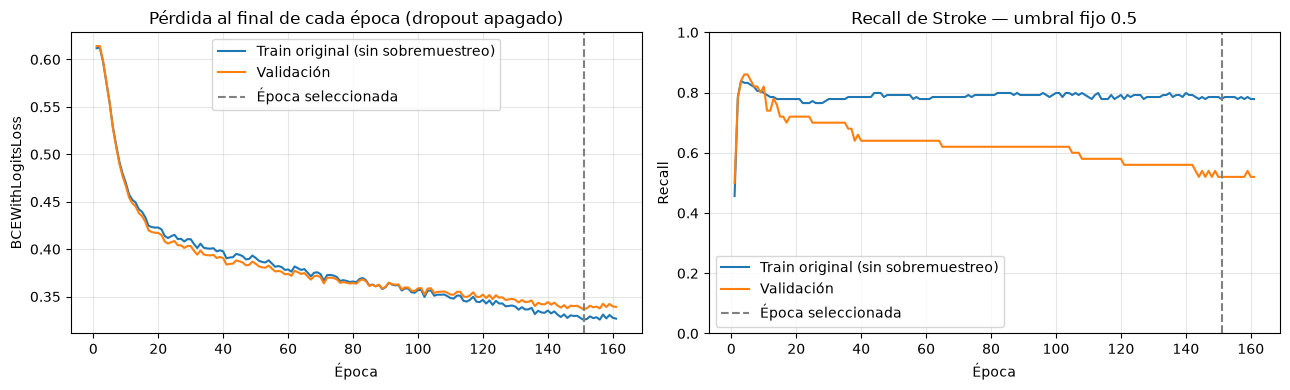

In [88]:
epochs_run = [row["epoch"] for row in history]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for prefix, label in [
    ("train", "Train original (sin sobremuestreo)"),
    ("val", "Validación"),
]:
    axes[0].plot(epochs_run, [row[f"{prefix}_loss"] for row in history], label=label)
    axes[1].plot(epochs_run, [row[f"{prefix}_recall"] for row in history], label=label)

axes[0].set_title("Pérdida al final de cada época (dropout apagado)")
axes[0].set_ylabel("BCEWithLogitsLoss")
axes[1].set_title("Recall de Stroke — umbral fijo 0.5")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.axvline(best_epoch, color="gray", linestyle="--", label="Época seleccionada")
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


## pos_weight
Como segundo método se decidió probar con pos_weight, dándole más peso a la clase minoritaria.

In [89]:
import copy
import random

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

X_tr_np = (
    X_train_prep.values if hasattr(X_train_prep, "values") else np.array(X_train_prep)
)
y_tr_np = y_train.values if hasattr(y_train, "values") else np.array(y_train)


X_train_t = torch.tensor(X_tr_np, dtype=torch.float32)
y_train_t = torch.tensor(y_tr_np, dtype=torch.float32).view(-1, 1)


batch_size = 64
dataset = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)


class CleanMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, dropout_rate=0.3):
        super(CleanMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_rate)
        self.fc2 = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        return self.fc2(x)


num_negatives = (y_tr_np == 0).sum()
num_positives = (y_tr_np == 1).sum()
if num_positives == 0 or num_negatives == 0:
    raise ValueError("Se requieren ambas clases en train.")
weight_val = num_negatives / num_positives

pos_weight = torch.tensor([weight_val], dtype=torch.float32)
print(f"Peso asignado a la clase 'Stroke': {weight_val:.2f}")

num_features = X_tr_np.shape[1]
model_pos_weight = CleanMLP(input_dim=num_features, hidden_dim=64, dropout_rate=0.3)

criterion_pos_weight = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer_pos_weight = optim.Adam(
    model_pos_weight.parameters(), lr=0.001, weight_decay=1e-4
)


# Train original: no se generan ni se usan ejemplos sintéticos.
train_dataset = dataset
train_eval_loader = DataLoader(train_dataset, batch_size=64, shuffle=False)
X_val_tensor = torch.tensor(np.asarray(X_val_prep), dtype=torch.float32)
y_val_tensor = torch.tensor(np.asarray(y_val), dtype=torch.float32).view(-1, 1)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)


def evaluar_pos_weight(loader):
    # eval() apaga dropout; no_grad() evita calcular gradientes.
    model_pos_weight.eval()
    loss_sum = 0.0
    total = 0
    true_positives = 0
    false_negatives = 0
    with torch.no_grad():
        for batch_x, batch_y in loader:
            logits = model_pos_weight(batch_x)
            loss_sum += criterion_pos_weight(logits, batch_y).item() * batch_x.size(0)
            total += batch_x.size(0)
            # Umbral fijo 0.5: equivale a logits >= 0. No se busca un umbral aquí.
            predictions = logits >= 0
            positives = batch_y == 1
            true_positives += (predictions & positives).sum().item()
            false_negatives += ((~predictions) & positives).sum().item()
    if total == 0:
        raise ValueError("No se puede evaluar un conjunto vacío.")
    positive_count = true_positives + false_negatives
    recall = true_positives / positive_count if positive_count else float("nan")
    return loss_sum / total, recall


epochs_pos_weight = 500
patience_pos_weight = 30
min_delta_pos_weight = 1e-4
best_val_loss_pos_weight = float("inf")
best_weights_pos_weight = None
best_epoch_pos_weight = None
bad_epochs_pos_weight = 0
history_pos_weight = []

print(
    "Train original ajusta pesos con pos_weight; validación selecciona la época; test no participa."
)
for epoch in range(1, epochs_pos_weight + 1):
    model_pos_weight.train()  # Reactivar dropout tras las evaluaciones de la época anterior.
    running_loss = 0.0
    for batch_x, batch_y in train_loader:
        optimizer_pos_weight.zero_grad()
        logits = model_pos_weight(batch_x)
        loss = criterion_pos_weight(logits, batch_y)
        loss.backward()
        optimizer_pos_weight.step()
        running_loss += loss.item() * batch_x.size(0)

    # Evaluación de train original y val con los mismos pesos y dropout apagado.
    train_loss, train_recall = evaluar_pos_weight(train_eval_loader)
    val_loss, val_recall = evaluar_pos_weight(val_loader)
    history_pos_weight.append(
        {
            "epoch": epoch,
            "optimization_loss": running_loss / len(train_dataset),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "train_recall": train_recall,
            "val_recall": val_recall,
        }
    )
    improved = val_loss < best_val_loss_pos_weight - min_delta_pos_weight
    if improved:
        best_val_loss_pos_weight = val_loss
        best_epoch_pos_weight = epoch
        # Copia independiente en memoria: no sobrescribe archivos de checkpoints.
        best_weights_pos_weight = copy.deepcopy(model_pos_weight.state_dict())
        bad_epochs_pos_weight = 0
    else:
        bad_epochs_pos_weight += 1

    # Todas las métricas siguen en history_pos_weight; solo se reduce la salida de consola.
    if epoch % 10 == 0 or bad_epochs_pos_weight == 1:
        status = (
            "Mejora de validación"
            if improved
            else f"Sin mejora suficiente | Paciencia: {bad_epochs_pos_weight}/{patience_pos_weight}"
        )
        print(
            f"Época {epoch:02d}/{epochs_pos_weight} | Loss train: {train_loss:.4f} "
            f"| Loss val: {val_loss:.4f} | Recall train: {train_recall:.3f} "
            f"| Recall val: {val_recall:.3f} | {status}"
        )

    if bad_epochs_pos_weight >= patience_pos_weight:
        print(f"Early stopping: {patience_pos_weight} épocas sin mejora suficiente.")
        break

if best_weights_pos_weight is None:
    raise RuntimeError("No se obtuvo un checkpoint válido; revisar datos y pérdidas.")
model_pos_weight.load_state_dict(best_weights_pos_weight)
model_pos_weight.eval()
print(
    f"Mejores pesos restaurados: época {best_epoch_pos_weight}, val loss = {best_val_loss_pos_weight:.4f}"
)


Peso asignado a la clase 'Stroke': 19.58
Train original ajusta pesos con pos_weight; validación selecciona la época; test no participa.
Época 10/500 | Loss train: 0.8788 | Loss val: 0.9009 | Recall train: 0.852 | Recall val: 0.880 | Mejora de validación
Época 12/500 | Loss train: 0.8717 | Loss val: 0.9017 | Recall train: 0.846 | Recall val: 0.840 | Sin mejora suficiente | Paciencia: 1/30
Época 14/500 | Loss train: 0.8673 | Loss val: 0.8997 | Recall train: 0.852 | Recall val: 0.860 | Sin mejora suficiente | Paciencia: 1/30
Época 17/500 | Loss train: 0.8614 | Loss val: 0.8981 | Recall train: 0.859 | Recall val: 0.860 | Sin mejora suficiente | Paciencia: 1/30
Época 20/500 | Loss train: 0.8558 | Loss val: 0.8959 | Recall train: 0.859 | Recall val: 0.860 | Sin mejora suficiente | Paciencia: 4/30
Época 30/500 | Loss train: 0.8392 | Loss val: 0.9094 | Recall train: 0.859 | Recall val: 0.820 | Sin mejora suficiente | Paciencia: 14/30
Época 40/500 | Loss train: 0.8235 | Loss val: 0.9130 | Recal

## Curvas de loss y recall con pos_weight

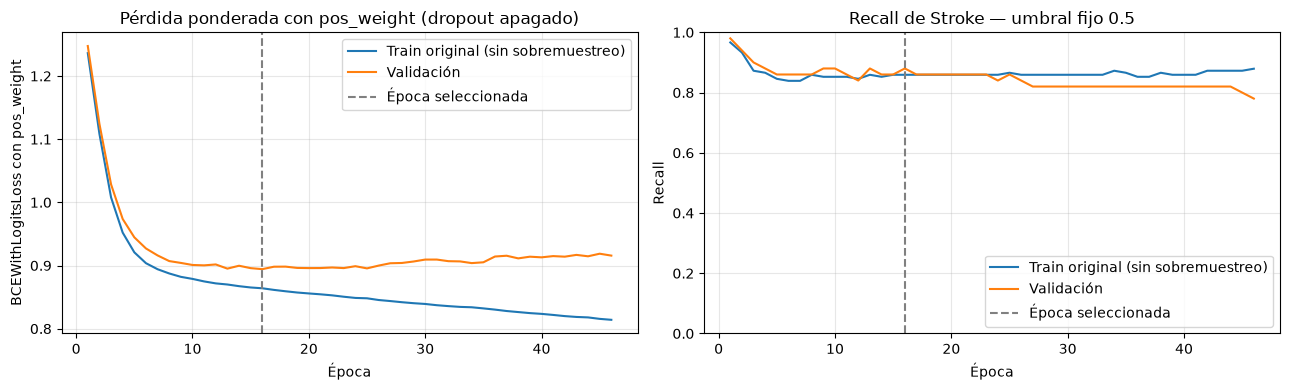

In [90]:
epochs_run = [row["epoch"] for row in history_pos_weight]
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for prefix, label in [
    ("train", "Train original (sin sobremuestreo)"),
    ("val", "Validación"),
]:
    axes[0].plot(
        epochs_run, [row[f"{prefix}_loss"] for row in history_pos_weight], label=label
    )
    axes[1].plot(
        epochs_run, [row[f"{prefix}_recall"] for row in history_pos_weight], label=label
    )

axes[0].set_title("Pérdida ponderada con pos_weight (dropout apagado)")
axes[0].set_ylabel("BCEWithLogitsLoss con pos_weight")
axes[1].set_title("Recall de Stroke — umbral fijo 0.5")
axes[1].set_ylabel("Recall")
axes[1].set_ylim(0, 1)
for ax in axes:
    ax.axvline(
        best_epoch_pos_weight, color="gray", linestyle="--", label="Época seleccionada"
    )
    ax.set_xlabel("Época")
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


scores

In [ ]:
from sklearn.metrics import fbeta_score, average_precision_score


def probabilidades_validacion(modelo, features):
    parameter = next(modelo.parameters())
    features_tensor = torch.tensor(
        np.asarray(features), dtype=torch.float32, device=parameter.device
    )
    modelo.eval()
    with torch.no_grad():
        probabilities = torch.sigmoid(modelo(features_tensor)).cpu().numpy().reshape(-1)
    if not np.isfinite(probabilities).all():
        raise ValueError("Se obtuvieron probabilidades no finitas.")
    return probabilities


def metricas_binarias(labels, probabilities, threshold):
    predictions = (probabilities >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "Umbral": float(threshold),
        "Accuracy": accuracy_score(labels, predictions),
        "Precision": precision_score(labels, predictions, zero_division=0),
        "Recall": recall_score(labels, predictions, zero_division=0),
        "F1": f1_score(labels, predictions, zero_division=0),
        "F2": fbeta_score(labels, predictions, beta=2, zero_division=0),
        "AUC_ROC": roc_auc_score(labels, probabilities),
        "AP": average_precision_score(labels, probabilities),
        "Especificidad": tn / (tn + fp),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
        "Alertas": int(tp + fp),
    }


def elegir_umbral_f2(labels, probabilities):
    # Una fila por umbral observado: cubre todos los cambios de clasificación.
    precision, recall, thresholds = precision_recall_curve(labels, probabilities)
    # El último punto de la curva no tiene un umbral asociado.
    precision, recall = precision[:-1], recall[:-1]
    denominator = 4 * precision + recall
    scores = np.divide(
        5 * precision * recall,
        denominator,
        out=np.zeros_like(denominator),
        where=denominator > 0,
    )
    candidates = pd.DataFrame(
        {
            "Umbral": thresholds,
            "Precision": precision,
            "Recall": recall,
            "F2": scores,
        }
    )
    denominator_f1 = precision + recall
    candidates["F1"] = np.divide(
        2 * precision * recall,
        denominator_f1,
        out=np.zeros_like(denominator_f1),
        where=denominator_f1 > 0,
    )
    # Empates numéricos en F2: preferir mayor precisión y luego mayor umbral.
    tied = candidates[
        np.isclose(candidates["F2"], candidates["F2"].max(), rtol=0, atol=1e-12)
    ]
    best = tied.sort_values(["Precision", "Umbral"], ascending=[False, False]).iloc[0]
    return float(best["Umbral"]), candidates


def elegir_umbral_f1(labels, probabilities):
    # Se conservan los mismos candidatos y la misma regla de desempate.
    _, candidates = elegir_umbral_f2(labels, probabilities)
    tied = candidates[
        np.isclose(candidates["F1"], candidates["F1"].max(), rtol=0, atol=1e-12)
    ]
    best = tied.sort_values(["Precision", "Umbral"], ascending=[False, False]).iloc[0]
    return float(best["Umbral"]), candidates


# Compatibilidad con un kernel donde el primer entrenamiento se ejecutó antes
# de agregar el nombre model_smote. El primer MLP sigue almacenado como model.
if "model_smote" not in globals():
    if "model" not in globals() or model.__class__.__name__ != "MLP":
        raise RuntimeError("Ejecutá primero el entrenamiento con SMOTE.")
    model_smote = copy.deepcopy(model)
if "model_pos_weight" not in globals():
    raise RuntimeError("Ejecutá primero el entrenamiento con pos_weight.")

labels_val = np.asarray(y_val).reshape(-1)
if set(np.unique(labels_val)) != {0, 1}:
    raise ValueError("Validación debe contener ambas clases.")
models_val = {
    "BorderlineSMOTE": model_smote,
    "pos_weight": model_pos_weight,
}
probabilities_val = {
    name: probabilidades_validacion(modelo, X_val_prep)
    for name, modelo in models_val.items()
}
if any(
    len(probabilities) != len(labels_val)
    for probabilities in probabilities_val.values()
):
    raise ValueError("Las predicciones deben estar alineadas con y_val.")

print(
    f"Validación: {len(labels_val)} pacientes; {int(labels_val.sum())} positivos "
    f"({labels_val.mean():.2%}). Ambos modelos usan las mismas filas."
)


Validación: 1022 pacientes; 50 positivos (4.89%). Ambos modelos usan las mismas filas.


comparación inicial con umbral 0.5

In [92]:
fixed_rows = [
    {
        "Modelo": name,
        "Regla": "Umbral 0.5",
        **metricas_binarias(labels_val, probabilities, 0.5),
    }
    for name, probabilities in probabilities_val.items()
]
fixed_rows.append(
    {
        "Modelo": "Referencia: siempre negativo",
        "Regla": "Umbral 0.5",
        **metricas_binarias(labels_val, np.zeros(len(labels_val)), 0.5),
    }
)
comparison_fixed = pd.DataFrame(fixed_rows)
display(comparison_fixed.round(4))


,Modelo,Regla,Umbral,Accuracy,Precision,Recall,F1,F2,AUC_ROC,AP,Especificidad,TN,FP,FN,TP,Alertas
0,BorderlineSMOTE,Umbral 0.5,0.5,0.8121,0.1340,0.52,0.2131,0.3299,0.8153,0.1644,0.8272,804,168,24,26,194
1,pos_weight,Umbral 0.5,0.5,0.7231,0.1371,0.88,0.2372,0.4223,0.8380,0.1631,0.7150,695,277,6,44,321
2,Referencia: siempre negativo,Umbral 0.5,0.5,0.9511,0.0000,0.00,0.0000,0.0000,0.5000,0.0489,1.0000,972,0,50,0,0


f1 y f2

In [ ]:
thresholds_f2 = {}
thresholds_f1 = {}
optimized_rows_f1 = []
threshold_curves = {}
optimized_rows = []
for name, probabilities in probabilities_val.items():
    threshold, candidates = elegir_umbral_f2(labels_val, probabilities)
    threshold_f1, _ = elegir_umbral_f1(labels_val, probabilities)
    thresholds_f1[name] = threshold_f1
    optimized_rows_f1.append(
        {
            "Modelo": name,
            "Regla": "Umbral elegido por F1 en val",
            **metricas_binarias(labels_val, probabilities, threshold_f1),
        }
    )
    thresholds_f2[name] = threshold
    threshold_curves[name] = candidates
    optimized_rows.append(
        {
            "Modelo": name,
            "Regla": "Umbral elegido por F2 en val",
            **metricas_binarias(labels_val, probabilities, threshold),
        }
    )
comparison_f2 = pd.DataFrame(optimized_rows)
comparison_f1 = pd.DataFrame(optimized_rows_f1)
comparison_thresholds = pd.concat([comparison_f1, comparison_f2], ignore_index=True)
display(comparison_thresholds.round(4))

# Selección reproducible por F2; en empate se prefiere precisión y luego recall.
ranked = comparison_f2.sort_values(
    ["F2", "Precision", "Recall", "Modelo"], ascending=[False, False, False, True]
)
selected_name = ranked.iloc[0]["Modelo"]
selected_model = models_val[selected_name]
selected_threshold = thresholds_f2[selected_name]
print(f"Configuración seleccionada en validación: {selected_name}")
print(f"Umbral que se conservaría para test: {selected_threshold:.6f}")


,Modelo,Regla,Umbral,Accuracy,Precision,Recall,F1,F2,AUC_ROC,AP,Especificidad,TN,FP,FN,TP,Alertas
0,BorderlineSMOTE,Umbral elegido por F1 en val,0.5513,0.8376,0.1506,0.50,0.2315,0.3415,0.8153,0.1644,0.8549,831,141,25,25,166
1,pos_weight,Umbral elegido por F1 en val,0.7138,0.8415,0.1706,0.58,0.2636,0.3919,0.8380,0.1631,0.8549,831,141,21,29,170
2,BorderlineSMOTE,Umbral elegido por F2 en val,0.2186,0.7387,0.1297,0.76,0.2216,0.3854,0.8153,0.1644,0.7377,717,255,12,38,293
3,pos_weight,Umbral elegido por F2 en val,0.5674,0.7583,0.1495,0.84,0.2538,0.4366,0.8380,0.1631,0.7541,733,239,8,42,281


Configuración seleccionada en validación: pos_weight
Umbral que se conservaría para test: 0.567368


matrices de confusión

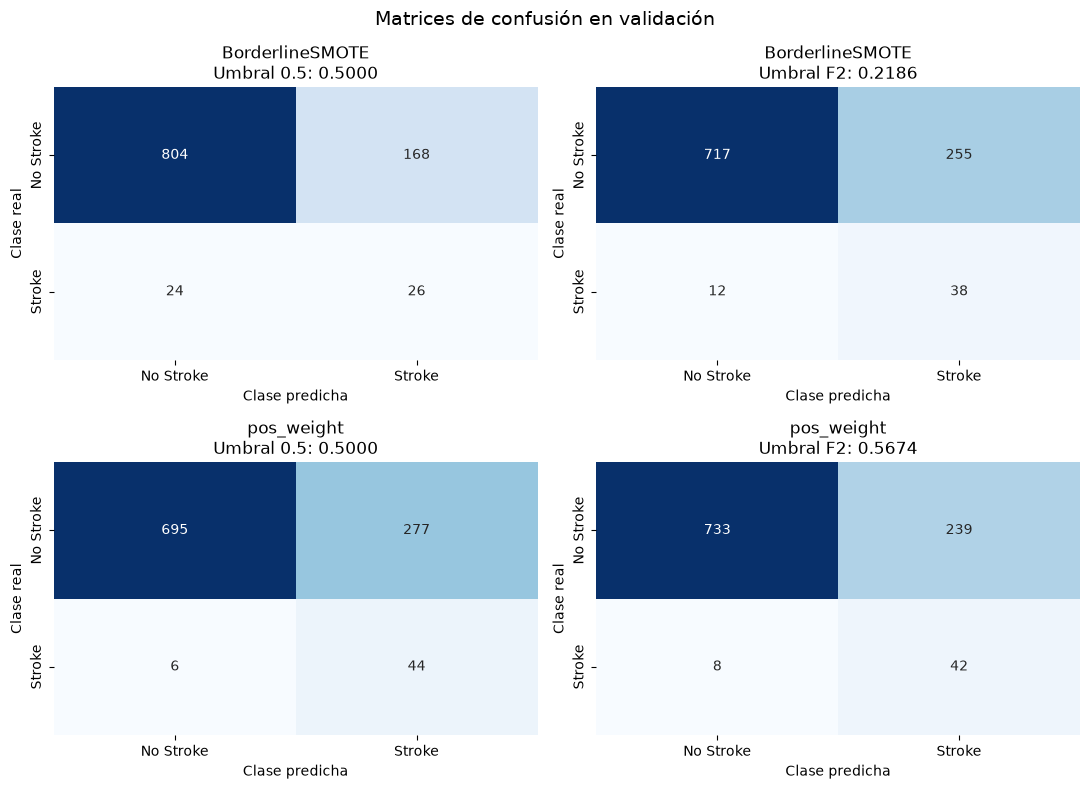

In [94]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for row, (name, probabilities) in enumerate(probabilities_val.items()):
    for col, (rule, threshold) in enumerate(
        [
            ("Umbral 0.5", 0.5),
            ("Umbral F2", thresholds_f2[name]),
        ]
    ):
        predictions = (probabilities >= threshold).astype(int)
        matrix = confusion_matrix(labels_val, predictions, labels=[0, 1])
        sns.heatmap(
            matrix,
            annot=True,
            fmt="d",
            cmap="Blues",
            cbar=False,
            xticklabels=["No Stroke", "Stroke"],
            yticklabels=["No Stroke", "Stroke"],
            ax=axes[row, col],
        )
        axes[row, col].set_title(f"{name}\n{rule}: {threshold:.4f}")
        axes[row, col].set_xlabel("Clase predicha")
        axes[row, col].set_ylabel("Clase real")
fig.suptitle("Matrices de confusión en validación", fontsize=14)
plt.tight_layout()
plt.show()


## Curvas roc, precisión-recall y métricas según umbral

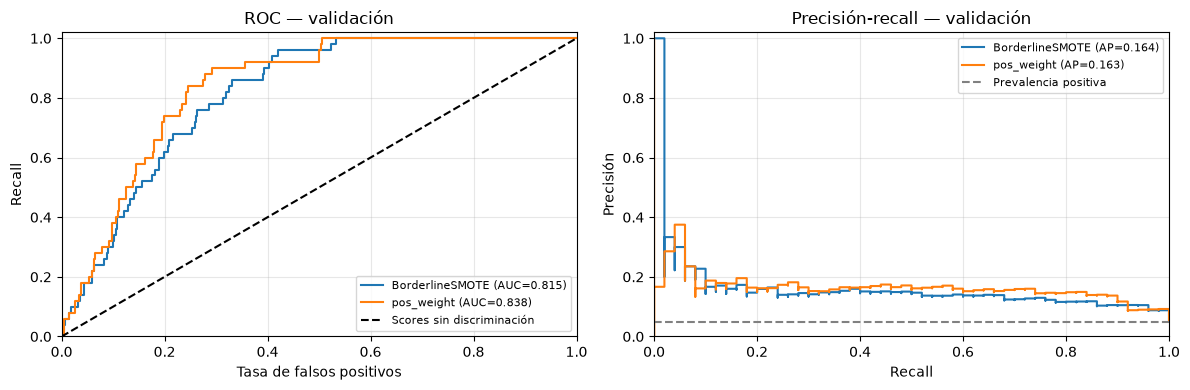

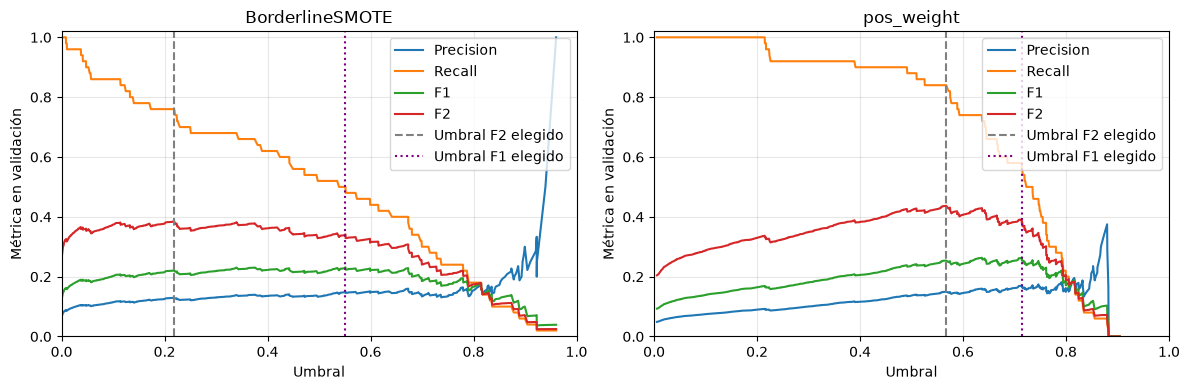

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for name, probabilities in probabilities_val.items():
    fpr, tpr, _ = roc_curve(labels_val, probabilities)
    precision, recall, _ = precision_recall_curve(labels_val, probabilities)
    axes[0].plot(
        fpr, tpr, label=f"{name} (AUC={roc_auc_score(labels_val, probabilities):.3f})"
    )
    axes[1].step(
        recall,
        precision,
        where="post",
        label=f"{name} (AP={average_precision_score(labels_val, probabilities):.3f})",
    )
axes[0].plot([0, 1], [0, 1], "k--", label="Scores sin discriminación")
axes[0].set(
    title="ROC — validación", xlabel="Tasa de falsos positivos", ylabel="Recall"
)
axes[1].axhline(
    labels_val.mean(), color="gray", linestyle="--", label="Prevalencia positiva"
)
axes[1].set(title="Precisión-recall — validación", xlabel="Recall", ylabel="Precisión")
for ax in axes:
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (name, candidates) in zip(axes, threshold_curves.items()):
    for metric in ["Precision", "Recall", "F1", "F2"]:
        ax.plot(candidates["Umbral"], candidates[metric], label=metric)
    ax.axvline(
        thresholds_f2[name], color="gray", linestyle="--", label="Umbral F2 elegido"
    )
    ax.axvline(
        thresholds_f1[name], color="purple", linestyle=":", label="Umbral F1 elegido"
    )
    ax.set(
        title=name,
        xlabel="Umbral",
        ylabel="Métrica en validación",
        xlim=(0, 1),
        ylim=(0, 1.02),
    )
    ax.grid(alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()
